### Multiple linear regression model 
### Dataset : UBER data

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [61]:
df = pd.read_csv("uber.csv")

### EDA

In [62]:
df.head()

,id,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [63]:
df.tail()

,id,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1
199999,11951496,2010-05-15 04:08:00.00000076,14.1,2010-05-15 04:08:00 UTC,-73.984395,40.720077,-73.985508,40.768793,1


In [64]:
df.isnull().sum()

id                   0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [65]:
df.dropna(inplace= True)

In [66]:
df.isnull().sum()

id                   0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [67]:
df.dtypes

id                     int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [68]:
df.corr

<bound method DataFrame.corr of               id                            key  fare_amount  \
0       24238194    2015-05-07 19:52:06.0000003          7.5   
1       27835199    2009-07-17 20:04:56.0000002          7.7   
2       44984355   2009-08-24 21:45:00.00000061         12.9   
3       25894730    2009-06-26 08:22:21.0000001          5.3   
4       17610152  2014-08-28 17:47:00.000000188         16.0   
...          ...                            ...          ...   
199995  42598914   2012-10-28 10:49:00.00000053          3.0   
199996  16382965    2014-03-14 01:09:00.0000008          7.5   
199997  27804658   2009-06-29 00:42:00.00000078         30.9   
199998  20259894    2015-05-20 14:56:25.0000004         14.5   
199999  11951496   2010-05-15 04:08:00.00000076         14.1   

                pickup_datetime  pickup_longitude  pickup_latitude  \
0       2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1       2009-07-17 20:04:56 UTC        -73.994355        40

In [69]:
df = df.dropna()  
df = df[df['fare_amount'] > 0]  

In [70]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['hour']= df['pickup_datetime'].dt.hour
df['day']= df['pickup_datetime'].dt.day
df['month']= df['pickup_datetime'].dt.month
df.head()

,id,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8


In [71]:
df.corr

<bound method DataFrame.corr of               id                            key  fare_amount  \
0       24238194    2015-05-07 19:52:06.0000003          7.5   
1       27835199    2009-07-17 20:04:56.0000002          7.7   
2       44984355   2009-08-24 21:45:00.00000061         12.9   
3       25894730    2009-06-26 08:22:21.0000001          5.3   
4       17610152  2014-08-28 17:47:00.000000188         16.0   
...          ...                            ...          ...   
199995  42598914   2012-10-28 10:49:00.00000053          3.0   
199996  16382965    2014-03-14 01:09:00.0000008          7.5   
199997  27804658   2009-06-29 00:42:00.00000078         30.9   
199998  20259894    2015-05-20 14:56:25.0000004         14.5   
199999  11951496   2010-05-15 04:08:00.00000076         14.1   

                 pickup_datetime  pickup_longitude  pickup_latitude  \
0      2015-05-07 19:52:06+00:00        -73.999817        40.738354   
1      2009-07-17 20:04:56+00:00        -73.994355       

In [72]:
# creating distance from latitudes and longitudes
# coded by gpt (cause idk how to do it)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)   

In [73]:

X = df[['passenger_count', 'hour', 'day', 'month','distance']]
y = df['fare_amount']

In [74]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [76]:
regression = LinearRegression(n_jobs = -1)
regression.fit(x_train_scaled, y_train )
regression.predict(x_train_scaled)

array([11.47774091, 11.55881417, 10.97438055, ..., 10.97688861,
       11.152141  , 11.2912084 ])

In [77]:
regression.coef_

array([ 0.1098883 , -0.19320164,  0.00857772,  0.23846923,  0.25542832])

In [78]:
regression.intercept_

11.35843100118139

In [79]:
y_test_pred =  regression.intercept_ + regression.coef_ * x_test_scaled

Text(0, 0.5, 'Predicted')

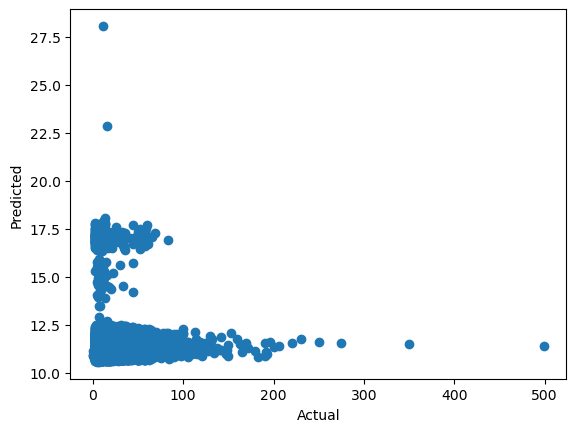

In [80]:
y_pred = regression.predict(x_train_scaled)

plt.scatter(y_train, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

### Performance metrics

In [81]:
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
adjusted_r2 = 1 - (1 - r2) * (len(y_train) - 1) / (len(y_train) - x_train_scaled.shape[1] - 1)
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")  
print(f"Adjusted R²: {adjusted_r2}")

MAE: 6.0411859204108485
MSE: 99.02018099508427
RMSE: 9.950888452549565
R²: 0.0017342472247798835
Adjusted R²: 0.0017030465448995002


### OLS prediction

In [82]:
import statsmodels.api as sm 
model = sm.OLS(y_train ,x_train_scaled).fit()
prediction1 = model.predict(x_test_scaled)
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:            fare_amount   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):              0.001
Method:                 Least Squares   F-statistic:                              24.14
Date:                Sat, 11 Apr 2026   Prob (F-statistic):                    2.30e-24
Time:                        00:15:41   Log-Likelihood:                     -6.6131e+05
No. Observations:              159981   AIC:                                  1.323e+06
Df Residuals:                  159976   BIC:                                  1.323e+06
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [83]:
print(prediction1)

[ 0.76249986  0.14761923 -0.2991402  ... -0.22311453 -0.57844687
  0.6654435 ]


### new data prediction

In [84]:
passenger_count = float(input("Enter passenger count: "))
hour = float(input("Enter hour (0-23): "))
day = float(input("Enter day (1-31): "))
month = float(input("Enter month (1-12): "))
distance = float(input("Enter distance (in km): "))
new_data = np.array([[passenger_count, hour, day, month, distance]])

new_data_scaled = scaler.transform(new_data)

prediction = regression.predict(new_data_scaled)

print("Estimated Fare:", prediction[0])

Estimated Fare: 11.489469355724209


c:\Users\ASHVITA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
